In [ ]:
import numpy as np #working with array
import pandas as pd #working with data set
import matplotlib.pyplot as plt # visualization
import yfinance as yf # data

import torch as torch# Machine Learning Neural Network  
import torch.nn as nn
import torch.optim as optim

from sklearn.preprocessing import StandardScaler # Scale Data + Evaluate Model
from sklearn.metrics import root_mean_squared_error



In [12]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

In [15]:
ticker = "MSFT"
df = yf.download(ticker, '2015-01-01')


/tmp/ipykernel_4810/2734660515.py:2: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(ticker, '2015-01-01')
[*********************100%***********************]  1 of 1 completed


In [16]:
df

Price,Close,High,Low,Open,Volume
Ticker,MSFT,MSFT,MSFT,MSFT,MSFT
Date,,,,,
2015-01-02,39.767681,40.328987,39.580581,39.682636,27913900
2015-01-05,39.401989,39.742173,39.333950,39.436005,39673900
2015-01-06,38.823677,39.759186,38.730126,39.444515,36447900
2015-01-07,39.316936,39.512543,38.687595,39.104321,29114100
2015-01-08,40.473583,40.609657,39.733680,39.759193,29645200
...,...,...,...,...,...
2026-04-22,432.920013,433.700012,423.670013,426.190002,29378200
2026-04-23,415.750000,423.660004,411.410004,419.890015,38308000


<Axes: xlabel='Date'>

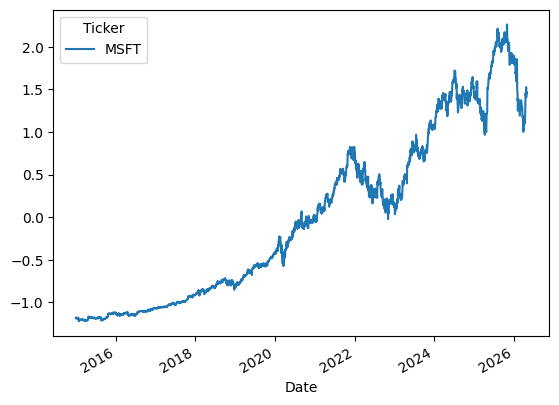

In [29]:
df.Close.plot()

In [27]:
#pre-processing data
scaler = StandardScaler()
df['Close'] = scaler.fit_transform(df['Close'])

In [28]:
df.Close

Ticker,MSFT
Date,
2015-01-02,-1.183387
2015-01-05,-1.185906
2015-01-06,-1.189890
2015-01-07,-1.186492
2015-01-08,-1.178524
...,...
2026-04-22,1.524943
2026-04-23,1.406663
2026-04-24,1.467766


In [ ]:
seq_len = 256
data = []

for i in range (len(df) - seq_len): # First 89 days to predict the 90th
    data.append(df.Close[i:i+seq_len])

data = np.array(data)

train_size = int(0.8*len(data))

#Sequential Prediction
X_train = torch.from_numpy(data[:train_size, -1, :]) # 1st dimen, 2nd dimen, 3rd dimen
Y_train = torch.from_numpy(data[:train_size, 1, :]) # 1st dimen, 2nd dimen, 3rd dimen
X_test = torch.from_numpy(data[train_size:, -1, :]) # 1st dimen, 2nd dimen, 3rd dimen
Y_test = torch.from_numpy(data[train_size:, -1, :]) # 1st dimen, 2nd dimen, 3rd dimen 


In [ ]:
class PricePrediction(nn.Module):
    def _init_(self, input_dim, hidden_dim, num_layers, output_dim):
        super(PricePrediction, self)._init_()
        self.num_layers = num_layers
        self.hidden_dim = self.hidden_dim

tensor([[-1.1434],
        [-1.1424],
        [-1.1426],
        ...,
        [ 1.3971],
        [ 1.4232],
        [ 1.4020]], dtype=torch.float64)

In [34]:
data.shape

(2590, 256, 1)